The code works as following: the function that does the GARCH fitting and subsequent simulation of the price path must be ensembled before hand. After that fit_GARCH_VaR() method outputs the desired arrays of the fitted Value-at-Risk values for the current day. In that file the 10 day VaR is used as a standard

In [87]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt

from Vares_simulations import *

from Vares import _terminal_returns, historical_var

Vares.ENABLE_TIMING = False

In [88]:
import pickle

#import the USD data 
with open('prices_usd.pkl', 'rb') as f: 
    prices_usd = pickle.load(f)

with open('original_returns_usd.pkl', 'rb') as f: 
    original_returns_usd = pickle.load(f)

with open('log_returns_usd.pkl', 'rb') as f: 
    log_returns_usd = pickle.load(f)    

original_returns_usd_scaled = original_returns_usd * 100
log_returns_usd_scaled = log_returns_usd * 100

In [89]:
def fit_GARCH_VaR(returns, garch_simulation: callable, lag=365, **kwargs): 
    time_series_length = returns.shape[0]
    avialable_lenth = time_series_length - lag
    VaRs = [0] * lag

    for t in range(avialable_lenth): 
        returns_sliced = returns[t:t+365]
        VaRs.append(garch_simulation(returns_sliced))

    return VaRs

Assessment of VaR modeled using other GARCHs

In [90]:
#Student GARCH

def student_GARCH_simulation(returns, horizon=10, n_paths=50_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=0, q=1, dist='t', rescale=False)
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    simulator = make_random_path_simulator_local_vol_student(parameters, 10, nu, granularity=granularity)

    sim_returns = _terminal_returns(simulator=simulator, n_paths=n_paths) 
    # print(sim_returns[sim_returns < -0.9])

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [91]:
student_vars = fit_GARCH_VaR(log_returns_usd, student_GARCH_simulation) 

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning:

The optimizer returned code 8. The message is:
Positive directional derivative for line

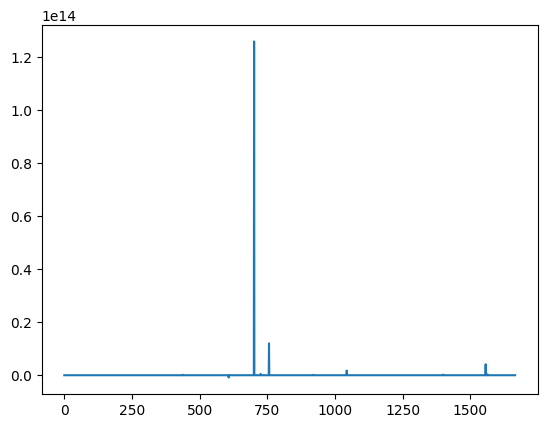

In [92]:
plt.plot(student_vars)

In [120]:
def normal_GARCH_simulation(returns, horizon=10, n_paths=500_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=0, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [110]:
norm_vars = fit_GARCH_VaR(log_returns_usd, normal_GARCH_simulation) 

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\P

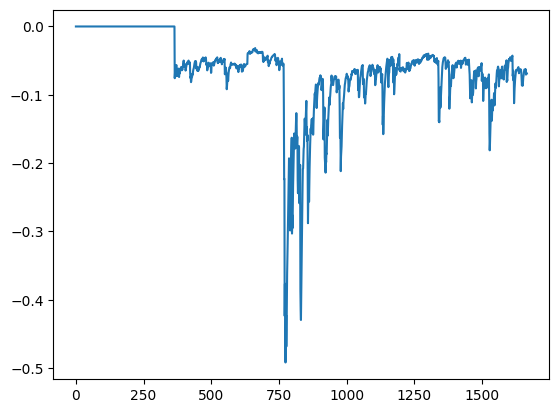

In [111]:
_norm_vars = np.multiply(norm_vars, -1)
plt.plot(_norm_vars)

In [122]:
def EGARCH_simulation(returns, horizon=10, n_paths=500_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='EGARCH', p=1, o=0, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [123]:
egarch_vars = fit_GARCH_VaR(log_returns_usd, normal_GARCH_simulation) 

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\P

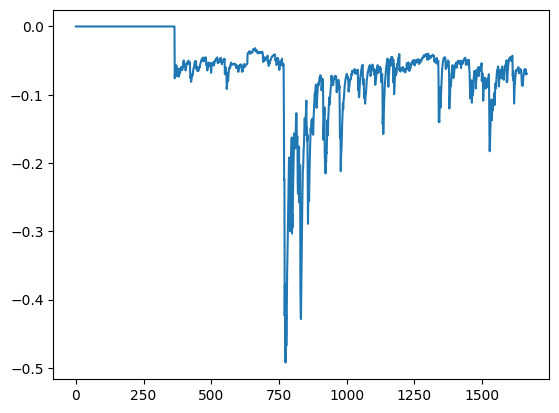

In [124]:
_egarch_vars = np.multiply(egarch_vars, -1)
plt.plot(_egarch_vars)

In [126]:
def GJRGARCH_simulation(returns, horizon=10, n_paths=500_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='GARCH', p=1, o=1, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    # forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)
    print(parameters)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

GJRGARCH_simulation(log_returns_usd[360:720])

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.089e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




SimParams(volatility=array([0.00642891, 0.00642545, 0.00642233, 0.00641952, 0.00641699,
       0.00641471, 0.00641266, 0.00641082, 0.00640916, 0.00640766]), mean=np.float64(-0.00015615437257406262))


Array(0.04868619, dtype=float64)

In [127]:
gjrgarch_vars = fit_GARCH_VaR(log_returns_usd, normal_GARCH_simulation) 

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\P

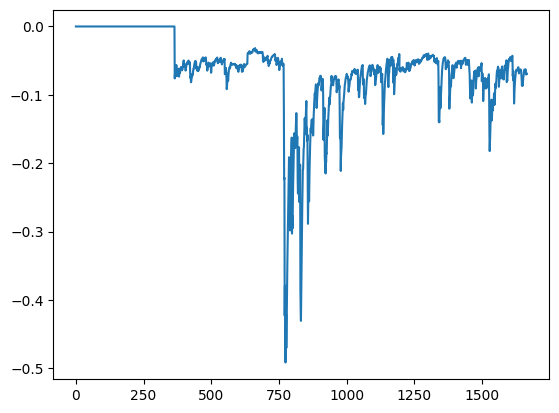

In [130]:
_gjrgarch_vars = np.multiply(gjrgarch_vars, -1)
plt.plot(_gjrgarch_vars)

In [131]:
def EGARCHo1_simulation(returns, horizon=10, n_paths=500_000, granularity=1, alpha=0.01): 
    model = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='normal')
    results = model.fit(disp='off')
    forecast = results.forecast(horizon=horizon)
    mu = results.params.get("mu", 0)
    sigma2 = forecast.variance.values[0]
    sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
    # nu = results.params.get('nu', 0)
    parameters = SimParams(volatility=sigma, mean=mu)

    # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
    sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

    # plt.hist(sim_returns, bins=50)
    # plt.show()

    VaR = historical_var(sim_returns, alpha)
    
    return VaR

In [132]:
egarcho1_vars = fit_GARCH_VaR(log_returns_usd, normal_GARCH_simulation) 

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\P

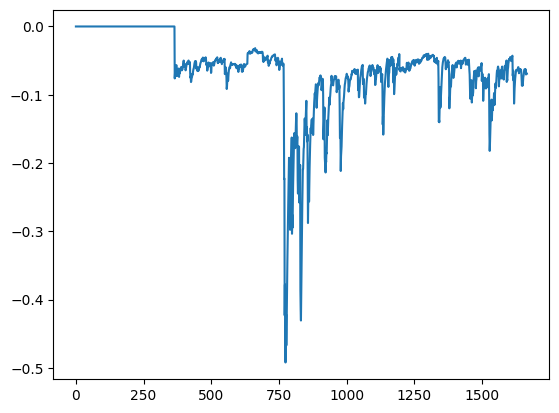

In [133]:
_egarcho1_vars = np.multiply(egarcho1_vars, -1)
plt.plot(_egarcho1_vars)

In [134]:
def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta) * price for log_delta, price in zip(var_array, prices)]

window = 10
cummulative_log_returns = np.convolve(log_returns_usd, np.ones(window), mode='valid')

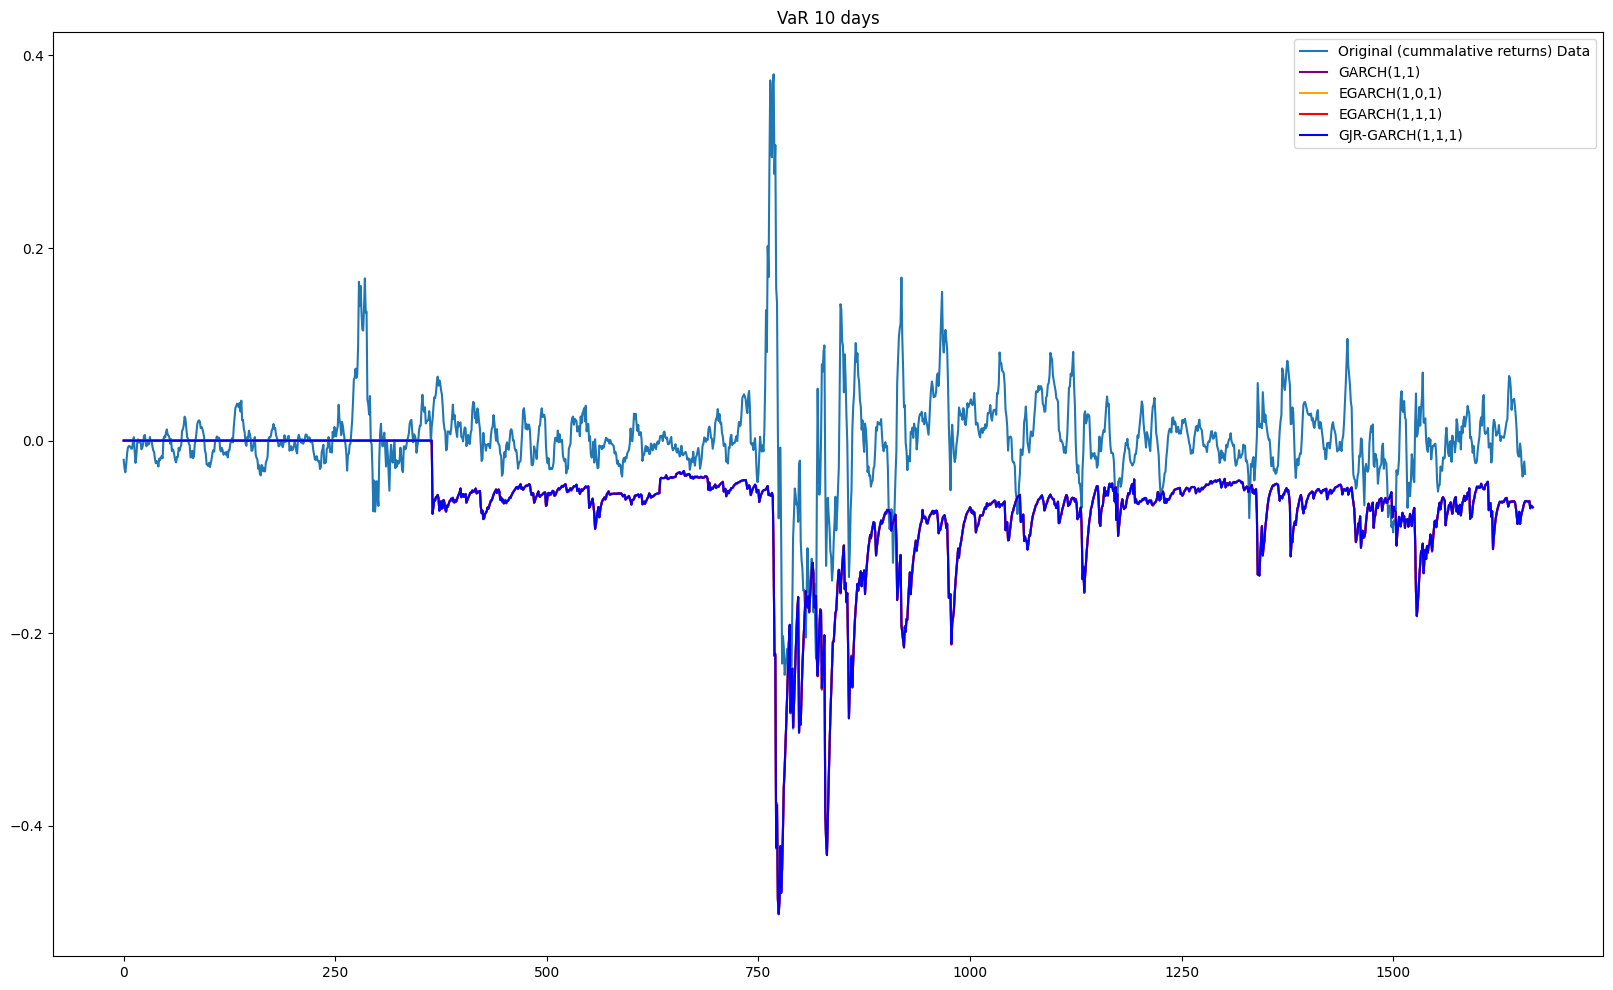

In [135]:
plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original (cummalative returns) Data')
plt.plot(_norm_vars, color='purple', label='GARCH(1,1)')
plt.plot(_egarch_vars, color='orange', label='EGARCH(1,0,1)')
plt.plot(_egarcho1_vars, color='red', label='EGARCH(1,1,1)')
plt.plot(_gjrgarch_vars, color='blue', label='GJR-GARCH(1,1,1)')
plt.title('VaR 10 days')
plt.legend()
plt.show()

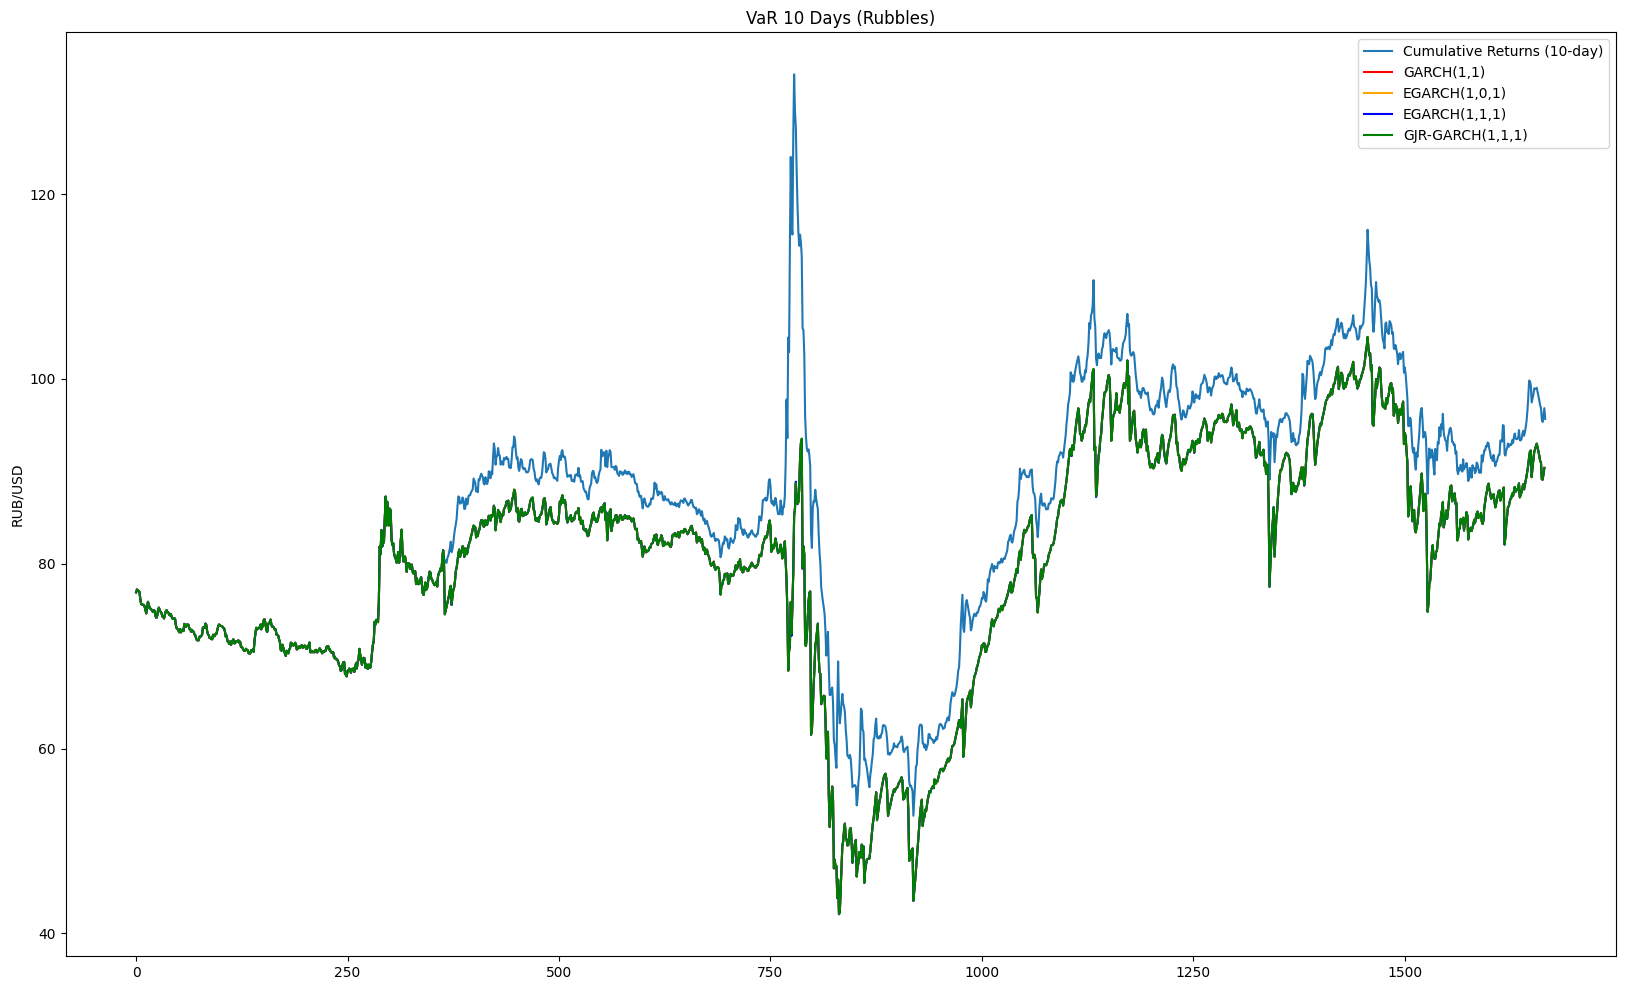

In [136]:
# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(_norm_vars, prices_usd), color='red', label='GARCH(1,1)')
plt.plot(turn_var_into_real_terms(_egarch_vars, prices_usd), color='orange', label='EGARCH(1,0,1)')
plt.plot(turn_var_into_real_terms(_egarcho1_vars, prices_usd), color='blue', label='EGARCH(1,1,1)')
plt.plot(turn_var_into_real_terms(_gjrgarch_vars, prices_usd), color='green', label='GJR-GARCH(1,1,1)')
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('RUB/USD')
plt.legend()
plt.show()

In [137]:
import plotly.graph_objects as go
import numpy as np

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='red', width=0.5),
    name='GARCH(1, 1)'
))

#Add EGARCH(1, 0, 1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarch_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='EGARCH(1, 0, 1)'
))

# Add Student's t CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_egarcho1_vars, prices_usd),
    mode='lines',
    line=dict(color='blue', width=0.5),
    name='EGARCH(1, 1, 1)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_gjrgarch_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='GJR-GARCH(1, 1, 1)'
))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()
